# Modules

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import MaxNLocator
from pathlib import Path
from scipy.stats import chi2_contingency, fisher_exact, ranksums

from longitudinal_arm_swing.constants import *

# Constants

In [ ]:
ids_excluded_by_category_filename = 'excluded_ids_by_category.json'
ids_remaining_filename = 'ids_remaining_after_exclusions.json'
dataset_ids_filename = 'dataset_ids.json'
med_info_filename = 'med_info_ids.json'
digital_measures_filename = 'digital_measures.parquet'
clinical_data_file_name = 'clinical_data.parquet'

path_measures = BASE_PATH / 'measures' / 'filtered_gait' / '20_inf'

start_week = 2
final_week_1y = 50
final_week_2y = 100

weeks_1y = np.arange(start_week, final_week_1y + 1, 2)
weeks_2y = np.arange(start_week, final_week_2y + 1, 2)

final_week_per_group = {
    'pd': final_week_2y,
    'controls': final_week_1y,
}

save_plots = True

# Load

In [ ]:
df_clinical = pd.read_parquet(PATH_CLINICAL_DATA / clinical_data_file_name)

with open(PATH_IDS / ids_excluded_by_category_filename, 'r') as f: 
    ids_excluded_by_category = json.load(f)

with open(PATH_IDS / ids_remaining_filename, 'r') as f:
    ids_remaining = json.load(f)

with open(PATH_IDS / dataset_ids_filename, 'r') as f:
    dataset_ids = json.load(f)

with open(PATH_IDS / med_info_filename, 'r') as f:
    med_info_ids = json.load(f)

with open(path_measures / 'pd_med_ids.txt', 'r') as f:
    pd_med_ids = f.read().splitlines()

with open(path_measures / 'pd_no_med_ids.txt', 'r') as f:
    pd_no_med_ids = f.read().splitlines()

pd_ids = pd_med_ids + pd_no_med_ids

with open(path_measures / 'controls_ids.txt', 'r') as f:
    controls_ids = f.read().splitlines()

with open(PATH_IDS / 'affected_side_ids.json', 'r') as f:
    affected_side_ids = json.load(f)

with open(PATH_IDS / 'srm_ids_per_week.json', 'r') as f:
    srm_ids_per_week = json.load(f)

digital_measures = pd.read_parquet(BASE_PATH / 'measures' / digital_measures_filename)

# Descriptive statistics 

### Cross-sectional

In [4]:
ppp_ids_clinical_excluded = [id for id in dataset_ids['ppp'] if any (id in v for _, v in ids_excluded_by_category['ppp']['cs']['clinical'].items())]
denovo_ids_clinical_excluded = [id for id in dataset_ids['denovo'] if any (id in v for _, v in ids_excluded_by_category['denovo']['cs']['clinical'].items())]
control_ids_clinical_excluded = [id for id in dataset_ids['controls'] if any (id in v for _, v in ids_excluded_by_category['controls']['cs']['clinical'].items())]

cs_ids_pre_exclusion = {
    'pd_mas': [id for id in dataset_ids['ppp'] + dataset_ids['denovo'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']],
    'pd_las': [id for id in dataset_ids['ppp'] + dataset_ids['denovo'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']],
    'controls': dataset_ids['controls'],
}

cs_ids_post_clinical_exclusion = {
    'pd_mas': [id for id in cs_ids_pre_exclusion['pd_mas'] if id not in ppp_ids_clinical_excluded and id not in denovo_ids_clinical_excluded and id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']],
    'pd_las': [id for id in cs_ids_pre_exclusion['pd_las'] if id not in ppp_ids_clinical_excluded and id not in denovo_ids_clinical_excluded and id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']],
    'controls': [id for id in cs_ids_pre_exclusion['controls'] if id not in control_ids_clinical_excluded],
}

cs_ids_post_measurement_exclusion = {
    'pd_mas': [id for id in ids_remaining['ppp']['cs'] + ids_remaining['denovo']['cs'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']],
    'pd_las': [id for id in ids_remaining['ppp']['cs'] + ids_remaining['denovo']['cs'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']],
    'controls': ids_remaining['controls']['cs'],
}

print(f"Number of participants before exclusions:\n- PD MAS: {len(cs_ids_pre_exclusion['pd_mas'])}\n- PD LAS: {len(cs_ids_pre_exclusion['pd_las'])}\n- Controls: {len(cs_ids_pre_exclusion['controls'])}\n")
print(f"Number of participants after clinical exclusions:\n- PD MAS: {len(cs_ids_post_clinical_exclusion['pd_mas'])}\n- PD LAS: {len(cs_ids_post_clinical_exclusion['pd_las'])}\n- Controls: {len(cs_ids_post_clinical_exclusion['controls'])}\n")
print(f"Number of participants after measurement exclusions:\n- PD MAS: {len(cs_ids_post_measurement_exclusion['pd_mas'])}\n- PD LAS: {len(cs_ids_post_measurement_exclusion['pd_las'])}\n- Controls: {len(cs_ids_post_measurement_exclusion['controls'])}")

Number of participants before exclusions:
- PD MAS: 392
- PD LAS: 221
- Controls: 50

Number of participants after clinical exclusions:
- PD MAS: 349
- PD LAS: 193
- Controls: 50

Number of participants after measurement exclusions:
- PD MAS: 294
- PD LAS: 165
- Controls: 45


In [5]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['cs']['clinical'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['cs']['clinical'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['cs']['clinical'].items()})

{'Walking aid': 54, 'At least significant dyskinesia': 15, 'Watch side unknown': 0, 'No clinical data': 0}
{'Walking aid': 4, 'At least significant dyskinesia': 0, 'Watch side unknown': 0, 'No clinical data': 0}
{'Walking aid': 0, 'At least significant dyskinesia': 0, 'Watch side unknown': 0, 'No clinical data': 0}


In [6]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['cs']['measurement'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['cs']['measurement'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['cs']['measurement'].items()})

{'No converted data': 3, 'No preprocessed data': 37, 'Insufficient sensor data': 9, 'No gait predicted': 4, 'No arm swing predicted': 1, 'No arm swing predicted in vlong gait segments': 5, 'Less than 2 valid arm swing days': 5}
{'No converted data': 7, 'No preprocessed data': 5, 'Insufficient sensor data': 5, 'No gait predicted': 0, 'No arm swing predicted': 1, 'No arm swing predicted in vlong gait segments': 1, 'Less than 2 valid arm swing days': 2}
{'No converted data': 1, 'No preprocessed data': 0, 'Insufficient sensor data': 3, 'No gait predicted': 0, 'No arm swing predicted': 1, 'No arm swing predicted in vlong gait segments': 0, 'Less than 2 valid arm swing days': 0}


In [7]:
updrs_scores = ['updrs_1_total', 'updrs_2_total', 'updrs_3_off_total', 'updrs_3_on_total', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws']

print(f"Cross-sectional IDs")

group_descr = {}
for group, group_ids in cs_ids_post_measurement_exclusion.items():
    group_descr[group] = {}
    df_clinical_group = df_clinical.loc[(df_clinical['id'].isin(group_ids)) & (df_clinical['visit']==1)]

    n_ids = len(group_ids)
    print(f"\n{group} (N = {len(group_ids)}):")

    n_female = df_clinical_group['Gender'].value_counts()[2]  # 1 == male, 2 == female
    perc_female = np.round(n_female / n_ids * 100, 1)
    print(f"N female = {n_female} ({perc_female}%)")

    mean_age = np.round(np.mean(df_clinical_group['Age']), 1)
    std_age = np.round(np.std(df_clinical_group['Age']), 1)
    print(f"Age: {mean_age} ({std_age})")

    n_domi_side = df_clinical_group.loc[
        ((df_clinical_group['WatchSide']=='left') & (df_clinical_group['PrefHand']==2)) |
        ((df_clinical_group['WatchSide']=='right') & (df_clinical_group['PrefHand']==1))
    ].shape[0]  # 1 == right, 2 == left, 3 == neither
    perc_domi_side = np.round(n_domi_side / n_ids * 100, 1)
    print(f"Dominant side: {n_domi_side} ({perc_domi_side}%)")

    group_descr[group]['gender'] = df_clinical_group['Gender'].values - 1
    group_descr[group]['age'] = df_clinical_group['Age'].values
    group_descr[group]['dominant_side'] = np.array(
        ((df_clinical_group['WatchSide']=='left') & (df_clinical_group['PrefHand']==2)) |
        ((df_clinical_group['WatchSide']=='right') & (df_clinical_group['PrefHand']==1))
    ).astype(int)
    
    if 'pd' in group:
        print(f"\nH&Y: {df_clinical_group['Up3OfHoeYah'].value_counts().sort_index()}\n")
        print(f"\nH&Y: {df_clinical_group['Up3OfHoeYah'].value_counts(normalize=True).sort_index() * 100}\n")

        group_descr[group]['hny'] = df_clinical_group['Up3OfHoeYah'].values

        for score in updrs_scores:
            print(f"{score}: {np.round(np.mean(df_clinical_group[score]), 1)} ({np.round(np.std(df_clinical_group[score]), 1)})")
            group_descr[group][score] = df_clinical_group[score].values

Cross-sectional IDs

pd_mas (N = 294):
N female = 113 (38.4%)
Age: 61.8 (9.1)
Dominant side: 77 (26.2%)

H&Y: Up3OfHoeYah
1.0     23
2.0    245
3.0     26
Name: count, dtype: int64


H&Y: Up3OfHoeYah
1.0     7.823129
2.0    83.333333
3.0     8.843537
Name: proportion, dtype: float64

updrs_1_total: 6.9 (3.7)
updrs_2_total: 6.1 (4.9)
updrs_3_off_total: 25.1 (9.6)
updrs_3_on_total: 22.5 (10.0)
updrs_3_hypokinesia_off_ws: 11.8 (4.0)
updrs_3_hypokinesia_on_ws: 10.5 (4.3)

pd_las (N = 165):
N female = 74 (44.8%)
Age: 61.8 (8.3)
Dominant side: 23 (13.9%)

H&Y: Up3OfHoeYah
1.0     11
2.0    140
3.0     14
Name: count, dtype: int64


H&Y: Up3OfHoeYah
1.0     6.666667
2.0    84.848485
3.0     8.484848
Name: proportion, dtype: float64

updrs_1_total: 7.0 (3.8)
updrs_2_total: 6.0 (4.7)
updrs_3_off_total: 24.4 (9.4)
updrs_3_on_total: 20.3 (9.3)
updrs_3_hypokinesia_off_ws: 7.8 (4.1)
updrs_3_hypokinesia_on_ws: 7.0 (4.3)

controls (N = 45):
N female = 29 (64.4%)
Age: 68.6 (7.5)
Dominant side: 8 (17.8

In [8]:
rounding_decimals = 1

# Optional: Only look at non-dominant arm
only_non_dominant_arm = False

if only_non_dominant_arm:
    domi_side_ids = df_clinical.loc[
        ((df_clinical['WatchSide']=='left') & (df_clinical['PrefHand']==2)) |
        ((df_clinical['WatchSide']=='right') & (df_clinical['PrefHand']==1)),
        'id'
    ].unique()

    digital_measures_focus = digital_measures.loc[~digital_measures['id'].isin(domi_side_ids)]
else:
    digital_measures_focus = digital_measures

gait_quantity = {}
for group in ['pd_mas', 'pd_las', 'controls']:
    print(f"\nGroup: {group}")
    gait_quantity[group] = {}

    if 'pd' in group:
        group_label = 'pd'
    else:
        group_label = 'controls'

    df_cs_group = digital_measures_focus.loc[
        (digital_measures_focus['id'].isin(cs_ids_post_measurement_exclusion[group])) &
        (digital_measures_focus['population']==group_label) & 
        (digital_measures_focus['week'] == start_week)
    ]

    n_ids = df_cs_group['id'].nunique()
    print(f"N = {n_ids}")

    # Amount of time spent in very long gait segments
    for filter_type in ['unfiltered', 'filtered']:
        gait_quantity[group][filter_type] = {}
        df_filter_type = df_cs_group.loc[df_cs_group['filter_type']==filter_type]

        print(f"Mean +/- SD amount of {filter_type} gait segments")
        for segment_category in ['0_20', '20_inf']:
            if group == 'pd':
                for aff_side in ['mas', 'las']:
                    hrs = df_filter_type.loc[df_filter_type['segment_category'] == segment_category, 'duration_s'].values / 3600
                    gait_quantity[group][filter_type][segment_category] = hrs

                    print(f"- {segment_category}: {np.round(np.mean(hrs), rounding_decimals)} +/- {np.round(np.std(hrs), rounding_decimals)} hours")
            else:
                hrs = df_filter_type.loc[df_filter_type['segment_category'] == segment_category, 'duration_s'].values / 3600
                gait_quantity[group][filter_type][segment_category] = hrs

                print(f"- {segment_category}: {np.round(np.mean(hrs), rounding_decimals)} +/- {np.round(np.std(hrs), rounding_decimals)} hours")

print("\nBetween-group differences")
for filter_type in ['unfiltered', 'filtered']:
    for segment_category in ['0_20', '20_inf']:
        for groups in [('pd_mas', 'pd_las'), ('pd_mas', 'controls'), ('pd_las', 'controls')]:
            group_1_hrs = gait_quantity[groups[0]][filter_type][segment_category]
            group_2_hrs = gait_quantity[groups[1]][filter_type][segment_category]
            print(f"{filter_type} - {segment_category} - {groups[0]} vs {groups[1]}: {ranksums(group_1_hrs, group_2_hrs)}")


Group: pd_mas
N = 294
Mean +/- SD amount of unfiltered gait segments
- 0_20: 4.1 +/- 1.4 hours
- 20_inf: 5.4 +/- 2.9 hours
Mean +/- SD amount of filtered gait segments
- 0_20: 0.8 +/- 0.5 hours
- 20_inf: 2.1 +/- 1.7 hours

Group: pd_las
N = 165
Mean +/- SD amount of unfiltered gait segments
- 0_20: 4.4 +/- 1.5 hours
- 20_inf: 5.4 +/- 3.3 hours
Mean +/- SD amount of filtered gait segments
- 0_20: 1.0 +/- 0.5 hours
- 20_inf: 2.5 +/- 2.0 hours

Group: controls
N = 45
Mean +/- SD amount of unfiltered gait segments
- 0_20: 5.2 +/- 1.7 hours
- 20_inf: 5.1 +/- 3.0 hours
Mean +/- SD amount of filtered gait segments
- 0_20: 1.3 +/- 0.6 hours
- 20_inf: 2.1 +/- 1.4 hours

Between-group differences
unfiltered - 0_20 - pd_mas vs pd_las: RanksumsResult(statistic=-2.56406837668503, pvalue=0.010345316179980819)
unfiltered - 0_20 - pd_mas vs controls: RanksumsResult(statistic=-4.164965639175215, pvalue=3.113994603805502e-05)
unfiltered - 0_20 - pd_las vs controls: RanksumsResult(statistic=-2.788343160

#### Compare groups

PD vs Controls, MAS vs LAS

In [9]:
var = 'dominant_side'
group_1 = 'pd_mas'
group_2 = 'controls'

print(f"Categorical variable: {var}")
print(f"{group_1} vs {group_2}\n")

pd_success = np.sum(group_descr[group_1][var])
pd_failure = len(group_descr[group_1][var]) - pd_success
controls_success = np.sum(group_descr[group_2][var])
controls_failure = len(group_descr[group_2][var]) - controls_success

contingency_table = np.array([[pd_success, pd_failure],
                               [controls_success, controls_failure]])

print("Contingency table:\n", contingency_table)

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: chi2={chi2:.4f}, p={p_chi2:.4f}")

oddsratio, p_fisher = fisher_exact(contingency_table)
print(f"Fisher's exact test: odds ratio={oddsratio:.4f}, p={p_fisher:.4f}")

Categorical variable: dominant_side
pd_mas vs controls

Contingency table:
 [[ 77 217]
 [  8  37]]
Chi-square test: chi2=1.0565, p=0.3040
Fisher's exact test: odds ratio=1.6411, p=0.2704


In [10]:
for var in ['age', 'hny', 'updrs_1_total', 'updrs_2_total', 'updrs_3_off_total', 'updrs_3_on_total', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws']:
    x = group_descr['pd_mas'][var]
    y = group_descr['pd_las'][var]

    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    
    if len(x) > 0 and len(y) > 0:
        stat, p = ranksums(x, y)
        print(f"{var}: statistic={stat:.3f}, p={p:.3f}")
    else:
        print(f"{var}: insufficient data")

age: statistic=0.300, p=0.765
hny: statistic=-0.129, p=0.898
updrs_1_total: statistic=-0.214, p=0.831
updrs_2_total: statistic=0.110, p=0.912
updrs_3_off_total: statistic=0.871, p=0.384
updrs_3_on_total: statistic=2.103, p=0.035
updrs_3_hypokinesia_off_ws: statistic=9.016, p=0.000
updrs_3_hypokinesia_on_ws: statistic=7.116, p=0.000


### Longitudinal
We consider the SRM statistics for the longitudinal population because we consider this the primary result

In [11]:
ppp_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['med'].items())]
ppp_no_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['no_med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['no_med'].items())]
denovo_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['med'].items())]
denovo_no_med_ids_clinical_excluded = [id for id in med_info_ids['groups']['no_med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['no_med'].items())]
control_ids_clinical_excluded = [id for id in dataset_ids['controls'] if any (id in v for k, v in ids_excluded_by_category['controls']['srm_1y']['clinical'].items())]

ppp_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['med'].items())]
ppp_no_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['no_med']['ppp'] if any (id in v for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['no_med'].items())]
denovo_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['med'].items())]
denovo_no_med_ids_measurement_excluded = [id for id in med_info_ids['groups']['no_med']['denovo'] if any (id in v for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['no_med'].items())]
control_ids_measurement_excluded = [id for id in dataset_ids['controls'] if any (id in v for k, v in ids_excluded_by_category['controls']['srm_1y']['measurement'].items())]

med_ids = [id for id in med_info_ids['groups']['med']['ppp'] + med_info_ids['groups']['med']['denovo'] if 'med' not in id]
no_med_ids = [id for id in med_info_ids['groups']['no_med']['ppp'] + med_info_ids['groups']['no_med']['denovo'] if 'no_med' not in id]
start_med_ids = [id for id in med_info_ids['groups']['no_med']['ppp'] + med_info_ids['groups']['no_med']['denovo'] if 'med' in id]

srm_ids_pre_exclusion = {
    'pd_med': med_ids,
    'pd_no_med': no_med_ids + start_med_ids,
    'controls': dataset_ids['controls'],
}

srm_ids_post_clinical_exclusion = {
    'pd_med': set([id for id in srm_ids_pre_exclusion['pd_med'] if id not in ppp_med_ids_clinical_excluded and id not in denovo_med_ids_clinical_excluded]),
    'pd_no_med': set([id for id in srm_ids_pre_exclusion['pd_no_med'] if id not in ppp_no_med_ids_clinical_excluded and id not in denovo_no_med_ids_clinical_excluded and id not in start_med_ids]),
    'controls': set([id for id in srm_ids_pre_exclusion['controls'] if id not in control_ids_clinical_excluded]),
}

srm_ids_post_measurement_exclusion = {
    'pd_med': set([id for id in srm_ids_post_clinical_exclusion['pd_med'] if id not in ppp_med_ids_measurement_excluded and id not in denovo_med_ids_measurement_excluded]),
    'pd_no_med': set([id for id in srm_ids_post_clinical_exclusion['pd_no_med'] if id not in ppp_no_med_ids_measurement_excluded and id not in denovo_no_med_ids_measurement_excluded]),
    'controls': set([id for id in srm_ids_post_clinical_exclusion['controls'] if id not in control_ids_measurement_excluded]),
}

print(f"Number of participants before exclusions:\n- PD med: {len(srm_ids_pre_exclusion['pd_med'])}\n- PD no med: {len(srm_ids_pre_exclusion['pd_no_med'])}\n- Controls: {len(srm_ids_pre_exclusion['controls'])}\n")
print(f"Number of participants after clinical exclusions:\n- PD med: {len(srm_ids_post_clinical_exclusion['pd_med'])}\n- PD no med {len(srm_ids_post_clinical_exclusion['pd_no_med'])}\n- Controls: {len(srm_ids_post_clinical_exclusion['controls'])}\n")
print(f"Number of participants after measurement exclusions:\n- PD med: {len(srm_ids_post_measurement_exclusion['pd_med'])}\n- PD no med {len(srm_ids_post_measurement_exclusion['pd_no_med'])}\n- Controls: {len(srm_ids_post_measurement_exclusion['controls'])}\n")

srm_ids_post_measurement_exclusion['pd_med_mas'] = [id for id in srm_ids_post_measurement_exclusion['pd_med'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']]
srm_ids_post_measurement_exclusion['pd_med_las'] = [id for id in srm_ids_post_measurement_exclusion['pd_med'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']]
srm_ids_post_measurement_exclusion['pd_no_med_mas'] = [id for id in srm_ids_post_measurement_exclusion['pd_no_med'] if id in affected_side_ids['ppp']['mas'] + affected_side_ids['denovo']['mas']]
srm_ids_post_measurement_exclusion['pd_no_med_las'] = [id for id in srm_ids_post_measurement_exclusion['pd_no_med'] if id in affected_side_ids['ppp']['las'] + affected_side_ids['denovo']['las']]

# Split PD by MAS and LAS
for aff_side in ['mas', 'las']:
    print(f"PD med {aff_side}: {len(srm_ids_post_measurement_exclusion['pd_med_' + aff_side])}")
    print(f"PD no med {aff_side}: {len(srm_ids_post_measurement_exclusion['pd_no_med_' + aff_side])}")

Number of participants before exclusions:
- PD med: 494
- PD no med: 127
- Controls: 50

Number of participants after clinical exclusions:
- PD med: 332
- PD no med 30
- Controls: 44

Number of participants after measurement exclusions:
- PD med: 313
- PD no med 24
- Controls: 29

PD med mas: 192
PD no med mas: 17
PD med las: 119
PD no med las: 5


In [12]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['clinical']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['clinical']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['srm_1y']['clinical'].items()})

{'Alternative diagnosis': 14, 'Walking aid in any visit': 98, 'At least significant dyskinesia in any visit': 44, 'Watch side switched during study': 14, 'No clinical data': 27, 'Watch side unknown': 0, 'Start medication week unknown': 0, 'Starting medication': 0}
{'Alternative diagnosis': 0, 'Walking aid in any visit': 0, 'At least significant dyskinesia in any visit': 0, 'Watch side switched during study': 0, 'No clinical data': 0, 'Watch side unknown': 0, 'Start medication week unknown': 0, 'Starting medication': 0}
{'Alternative diagnosis': 1, 'Walking aid in any visit': 2, 'At least significant dyskinesia in any visit': 0, 'Watch side switched during study': 0, 'No clinical data': 1, 'Watch side unknown': 0, 'Start medication week unknown': 7, 'Starting medication': 5}
{'Alternative diagnosis': 0, 'Walking aid in any visit': 5, 'At least significant dyskinesia in any visit': 1, 'Watch side switched during study': 11, 'No clinical data': 28, 'Watch side unknown': 0, 'Start medicati

In [13]:
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['ppp']['srm_2y']['measurement']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['denovo']['srm_2y']['measurement']['no_med'].items()})
print({k: len(v) for k, v in ids_excluded_by_category['controls']['srm_1y']['measurement'].items()})

{'Insufficient sensor data in first 6 weeks': 9, 'Insufficient sensor data in last 6 weeks': 7, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 1, 'No valid arm swing data in first 6 weeks': 1, 'No valid arm swing data in last 6 weeks': 1}
{'Insufficient sensor data in first 6 weeks': 0, 'Insufficient sensor data in last 6 weeks': 0, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 0, 'No valid arm swing data in first 6 weeks': 0, 'No valid arm swing data in last 6 weeks': 0}
{'Insufficient sensor data in first 6 weeks': 0, 'Insufficient sensor data in last 6 weeks': 0, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 0, 'No valid arm swing data in first 6 weeks': 0, 'No valid arm swing data in last 6 weeks': 0}
{'Insufficient sensor data in first 6 weeks': 1, 'Insufficient sensor data in last 6 weeks': 5, 'No arm swing data in first 6 weeks': 0, 'No arm swing data in last 6 weeks': 0, 'No valid arm

In [15]:
updrs_scores = ['updrs_1_total', 'updrs_2_total', 'updrs_3_off_total', 'updrs_3_on_total', 'updrs_3_hypokinesia_off_ws', 'updrs_3_hypokinesia_on_ws']

print(f"Longitudinal IDs")

group_descr = {}
for group, group_ids in srm_ids_post_measurement_exclusion.items():
    if group in ['pd_med', 'pd_no_med']:
        continue

    group_descr[group] = {}
    n_ids = len(group_ids)

    df_clinical_group = df_clinical.loc[(df_clinical['id'].isin(group_ids)) & (df_clinical['visit']==1)].copy()
    print(f"\n{group} - N = {n_ids}")
    n_female = df_clinical_group['Gender'].value_counts()[2]  # 1 == male, 2 == female
    perc_female = np.round(n_female / n_ids * 100, 1)

    print(f"N female = {n_female} ({perc_female}%)")

    mean_age = np.round(np.mean(df_clinical_group['Age']), 1)
    std_age = np.round(np.std(df_clinical_group['Age']), 1)
    print(f"Age: {mean_age} ({std_age})")

    df_clinical_group.loc[
        ((df_clinical_group['WatchSide']=='left') & (df_clinical_group['PrefHand']==2)) |
        ((df_clinical_group['WatchSide']=='right') & (df_clinical_group['PrefHand']==1)),
        'domi_side'
    ] = 1 # 1 == right, 2 == left, 3 == neither
    n_domi_side = df_clinical_group['domi_side'].value_counts().get(1, 0)
    perc_domi_side = np.round(n_domi_side / n_ids * 100, 1)
    print(f"Dominant side: N = {n_domi_side} ({perc_domi_side}%)")

    group_descr[group]['n_ids'] = n_ids
    group_descr[group]['gender'] = df_clinical_group['Gender'].values - 1
    group_descr[group]['age'] = df_clinical_group['Age'].values
    group_descr[group]['domi_side'] = df_clinical_group['domi_side'].values

    if group != 'controls':
        n_mas = df_clinical_group.loc[df_clinical_group['affected_side']=='mas'].shape[0]
        perc_mas = np.round(n_mas / n_ids * 100, 1)
    
        print(f"Most affected side: {perc_mas}")
        print(f"\nH&Y (N): {df_clinical_group['Up3OfHoeYah'].value_counts().sort_index()}\n")
        print(f"\nH&Y (%): {df_clinical_group['Up3OfHoeYah'].value_counts(normalize=True).sort_index() * 100}\n")

        group_descr[group]['n_hy'] = df_clinical_group['Up3OfHoeYah'].value_counts().sort_index().to_dict()

        for score in updrs_scores:
            print(f"{score}: {np.round(np.mean(df_clinical_group[score]), 1)} ({np.round(np.std(df_clinical_group[score]), 1)})")
            group_descr[group][score] = df_clinical_group[score]

Longitudinal IDs

controls - N = 29
N female = 16 (55.2%)
Age: 70.7 (8.3)
Dominant side: N = 7 (24.1%)

pd_med_mas - N = 192
N female = 70 (36.5%)
Age: 61.6 (8.7)
Dominant side: N = 40 (20.8%)
Most affected side: 100.0

H&Y (N): Up3OfHoeYah
1.0     17
2.0    155
3.0     20
Name: count, dtype: int64


H&Y (%): Up3OfHoeYah
1.0     8.854167
2.0    80.729167
3.0    10.416667
Name: proportion, dtype: float64

updrs_1_total: 7.3 (3.4)
updrs_2_total: 6.3 (4.7)
updrs_3_off_total: 24.2 (9.4)
updrs_3_on_total: 21.2 (9.3)
updrs_3_hypokinesia_off_ws: 11.4 (4.0)
updrs_3_hypokinesia_on_ws: 10.1 (4.1)

pd_med_las - N = 119
N female = 55 (46.2%)
Age: 62.0 (7.5)
Dominant side: N = 17 (14.3%)
Most affected side: 0.0

H&Y (N): Up3OfHoeYah
1.0     8
2.0    99
3.0    12
Name: count, dtype: int64


H&Y (%): Up3OfHoeYah
1.0     6.722689
2.0    83.193277
3.0    10.084034
Name: proportion, dtype: float64

updrs_1_total: 7.0 (3.9)
updrs_2_total: 5.4 (4.4)
updrs_3_off_total: 22.8 (9.0)
updrs_3_on_total: 19.4 (8.

In [16]:
group_1 = 'pd_med_mas'
group_2 = 'pd_med_las'
measure = 'domi_side'

pd_med_success = np.nansum(group_descr[group_1][measure])
pd_med_failure = len(group_descr[group_1][measure]) - pd_med_success
pd_no_med_success = np.nansum(group_descr[group_2][measure])
pd_no_med_failure = len(group_descr[group_2][measure]) - pd_no_med_success

contingency_table = np.array([[pd_med_success, pd_med_failure],
                               [pd_no_med_success, pd_no_med_failure]])

print("Contingency table:\n", contingency_table)

chi2, p_chi2, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square test: chi2={chi2:.4f}, p={p_chi2:.4f}")

oddsratio, p_fisher = fisher_exact(contingency_table)
print(f"Fisher's exact test: odds ratio={oddsratio:.4f}, p={p_fisher:.4f}")

Contingency table:
 [[ 40. 152.]
 [ 17. 102.]]
Chi-square test: chi2=1.6894, p=0.1937
Fisher's exact test: odds ratio=1.5789, p=0.1753


### Amount of gait longitudinally

Number of participants per group at baseline:

filtered gait
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 15 MAS, 4 LAS
- Controls: 28


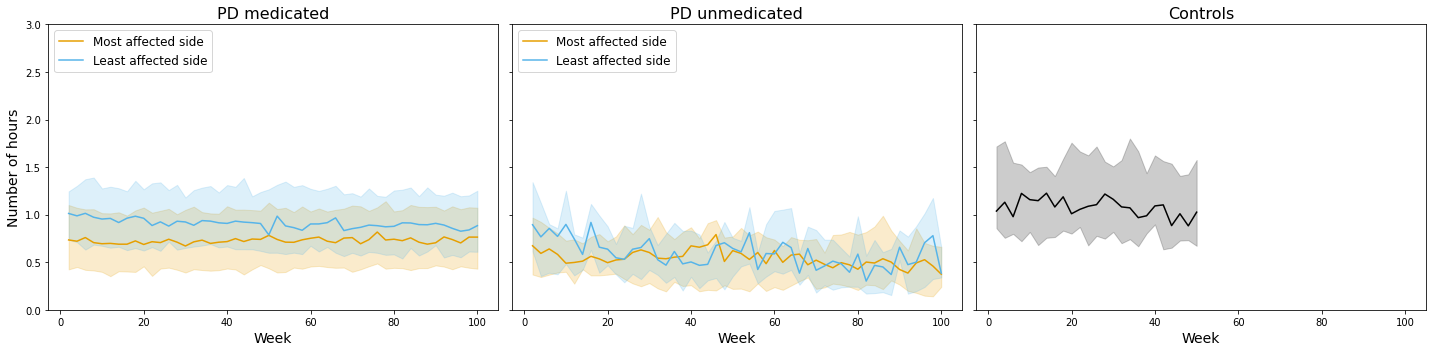

In [18]:
static_or_dynamic = 'static'
filter_type = 'filtered'
segment_length = '0_20'

fig, ax = plt.subplots(ncols=3, figsize=(20, 5), sharex=True, sharey=True)

print(f"Number of participants per group at baseline:")
print(f"\n{filter_type} gait")
for j, group in enumerate(['pd_med', 'pd_no_med', 'controls']):
    if 'pd' in group:
        weeks = weeks_2y
        population = 'pd'
        med_state = group.split('pd_')[1]
    else:
        weeks = weeks_1y
        population = 'controls'

    df_lng_group = digital_measures.loc[
        (digital_measures['population']==population) & 
        (digital_measures['segment_category'] == segment_length) &
        (digital_measures['filter_type'] == filter_type)
    ]

    iqr_list = []
    for week in weeks:
        if population == 'pd':
            for aff_side in ['mas', 'las']:
                if static_or_dynamic == 'static':
                    valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(final_week_2y)]
                else:
                    valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(week)]
                df_week = df_lng_group.loc[
                    (df_lng_group['week'] == week) &
                    (df_lng_group['affected_side'] == aff_side) &
                    (df_lng_group['id'].isin(valid_ids)) &
                    (df_lng_group['sufficient_arm_swing_this_week'])
                ]

                iqr_list.append([
                    week,
                    aff_side,
                    np.percentile(df_week['duration_s'] / 3600, 25), 
                    np.percentile(df_week['duration_s'] / 3600, 50), 
                    np.percentile(df_week['duration_s'] / 3600, 75)
                ])   

                if week == start_week and aff_side == 'mas':
                    N_mas = df_week['id'].nunique()
                elif week == start_week:
                    N_las = df_week['id'].nunique()
        else:
            if static_or_dynamic == 'static':
                valid_ids = srm_ids_per_week[segment_length][population][str(final_week_1y)]
            else:
                valid_ids = srm_ids_per_week[segment_length][population][str(week)]
            df_week = df_lng_group.loc[
                (df_lng_group['week'] == week) & 
                (df_lng_group['id'].isin(valid_ids)) &
                (df_lng_group['sufficient_arm_swing_this_week'])
            ]

            iqr_list.append([
                week,
                aff_side,
                np.percentile(df_week['duration_s'] / 3600, 25), 
                np.percentile(df_week['duration_s'] / 3600, 50), 
                np.percentile(df_week['duration_s'] / 3600, 75)
            ])   
        
            if week == start_week:
                N = df_week['id'].nunique()

    df_iqr = pd.DataFrame(iqr_list)
    df_iqr.columns = ['week', 'aff_side', '25p', '50p', '75p']

    if population == 'pd':
        for aff_side, color in zip(['mas', 'las'], [COLOR_GROUP_1, COLOR_GROUP_2]):
            df_aff = df_iqr.loc[df_iqr['aff_side']==aff_side]
            sns.lineplot(df_aff, x='week', y='50p', ax=ax[j], label=f'{AFFECTED_SIDE_RENAMING[aff_side]}', color=color)
            ax[j].fill_between(df_aff['week'], df_aff['25p'], df_aff['75p'], alpha=0.2, color=color)

        ax[j].legend(loc='upper left', fontsize=12)
    else:
        sns.lineplot(df_iqr, x='week', y='50p', ax=ax[j], label='', color='black')
        ax[j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black')

    ax[j].set_ylim([0, 3])

    ax[j].set_title(f'{GROUP_RENAMING[group]}', size=16)
    ax[j].set_ylabel('Number of hours', size=14)
    ax[j].set_xlabel('Week', size=14)
    

    if population == 'pd':
        print(f"- {GROUP_RENAMING[group]}: {N_mas} MAS, {N_las} LAS")
    else:
        print(f"- {GROUP_RENAMING[group]}: {N}")

plt.tight_layout()
plt.show()

Amount of unfiltered gait
- PD medicated: 289
- PD medicated - Start week hours - 0_20: 4.3 +/- 1.5 hours
- PD medicated - Final week hours - 0_20: 4.0 +/- 1.6 hours
- PD medicated - Difference in hours - WilcoxonResult(statistic=15643.0, pvalue=0.00018847710492023466)
- PD unmedicated: 14
- PD unmedicated - Start week hours - 0_20: 4.1 +/- 1.9 hours
- PD unmedicated - Final week hours - 0_20: 3.3 +/- 1.6 hours
- PD unmedicated - Difference in hours - WilcoxonResult(statistic=24.0, pvalue=0.0784912109375)
- Controls: 29
- Controls - Start week hours - 0_20: 4.9 +/- 1.9 hours
- Controls - Final week hours - 0_20: 5.0 +/- 2.0 hours
- Controls - Difference in hours - WilcoxonResult(statistic=143.0, pvalue=0.8553357124328613)
- PD medicated: 289
- PD medicated - Start week hours - 20_inf: 5.2 +/- 3.0 hours
- PD medicated - Final week hours - 20_inf: 4.7 +/- 2.8 hours
- PD medicated - Difference in hours - WilcoxonResult(statistic=16832.0, pvalue=0.003757907121633839)
- PD unmedicated: 14
-

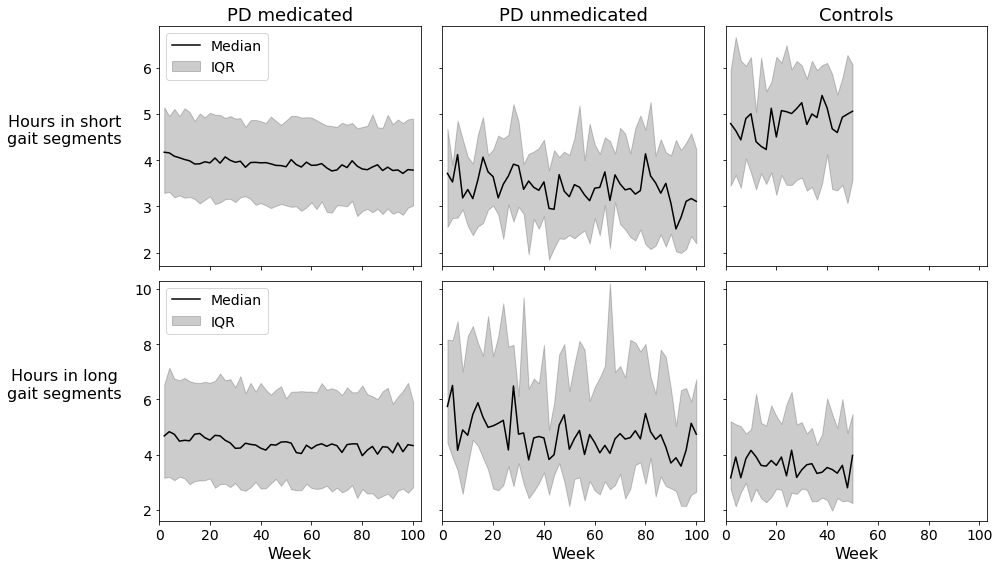

In [19]:
from scipy.stats import wilcoxon
from matplotlib.ticker import MultipleLocator

static_or_dynamic = 'static'
filter_type = 'unfiltered'

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(14, 8), sharex=True, sharey=False)

print(f"Amount of {filter_type} gait")

rounding_decimals = 1

for i, segment_length in enumerate(['0_20', '20_inf']):
    for j, group in enumerate(['pd_med', 'pd_no_med', 'controls']):
        if 'pd' in group:
            weeks = weeks_2y
            final_week = final_week_2y
            population = 'pd'
            med_state = group.split('pd_')[1]
        else:
            weeks = weeks_1y
            final_week = final_week_1y
            population = 'controls'

        df_lng_group = digital_measures.loc[
            (digital_measures['population']==population) & 
            (digital_measures['segment_category'] == segment_length) &
            (digital_measures['filter_type'] == filter_type)
        ]

        if filter_type == 'filtered':
            df_lng_group = df_lng_group.loc[digital_measures['sufficient_arm_swing_this_week']]

        start_week_ids = df_lng_group.loc[df_lng_group['week'] == start_week, 'id'].unique()
        final_week_ids = df_lng_group.loc[df_lng_group['week'] == final_week, 'id'].unique()
        valid_ids_start_end = [x for x in start_week_ids if x in final_week_ids]

        iqr_list = []
        for week in weeks:
            if population == 'pd':
                final_week_ids = df_lng_group.loc[df_lng_group['week']==final_week_2y, 'id'].unique()
                if static_or_dynamic == 'static':
                    valid_ids = [x for x in srm_ids_per_week[segment_length][f'{population}_mas_{med_state}'][str(final_week_2y)] + srm_ids_per_week[segment_length][f'{population}_las_{med_state}'][str(final_week_2y)] if x in final_week_ids]
                    ids_both_weeks = [id for id in valid_ids if id in srm_ids_per_week[segment_length][f'{population}_mas_{med_state}'][str(start_week)] + srm_ids_per_week[segment_length][f'{population}_las_{med_state}'][str(start_week)]]
                else:
                    valid_ids = srm_ids_per_week[segment_length][f'{population}_mas_{med_state}'][str(week)] + srm_ids_per_week[segment_length][f'{population}_las_{med_state}'][str(week)]
                    
                df_week = df_lng_group.loc[
                    (df_lng_group['week'] == week) &
                    (df_lng_group['id'].isin(valid_ids))
                ]

                iqr_list.append([
                    week,
                    np.percentile(df_week['duration_s'] / 3600, 25), 
                    np.percentile(df_week['duration_s'] / 3600, 50), 
                    np.percentile(df_week['duration_s'] / 3600, 75)
                ])   

                if week == start_week:
                    N = df_week['id'].nunique()
            else:
                if static_or_dynamic == 'static':
                    valid_ids = srm_ids_per_week[segment_length][population][str(final_week_1y)]
                    ids_both_weeks = [id for id in srm_ids_per_week[segment_length][population][str(start_week)] if id in valid_ids]
                else:
                    valid_ids = srm_ids_per_week[segment_length][population][str(week)]

                df_week = df_lng_group.loc[
                    (df_lng_group['week'] == week) & 
                    (df_lng_group['id'].isin(valid_ids))
                ]

                iqr_list.append([
                    week,
                    np.percentile(df_week['duration_s'] / 3600, 25), 
                    np.percentile(df_week['duration_s'] / 3600, 50), 
                    np.percentile(df_week['duration_s'] / 3600, 75)
                ])   
            
                if week == start_week:
                    N = df_week['id'].nunique()


            if week == start_week:
                start_week_hrs = df_week.loc[df_week['id'].isin(valid_ids_start_end), 'duration_s'].values / 3600
                print(f"- {GROUP_RENAMING[group]}: {N}")
                print(f"- {GROUP_RENAMING[group]} - Start week hours - {segment_length}: {np.round(np.nanmean(start_week_hrs), rounding_decimals)} +/- {np.round(np.nanstd(start_week_hrs), rounding_decimals)} hours")
            elif week == final_week_2y and 'pd' in group or week == final_week_1y and group == 'controls':
                final_week_hrs = df_week.loc[df_week['id'].isin(valid_ids_start_end), 'duration_s'].values / 3600
                print(f"- {GROUP_RENAMING[group]} - Final week hours - {segment_length}: {np.round(np.nanmean(final_week_hrs), rounding_decimals)} +/- {np.round(np.nanstd(final_week_hrs), rounding_decimals)} hours")

                # Wilcoxon signed-rank test?
                print(f"- {GROUP_RENAMING[group]} - Difference in hours - {wilcoxon(start_week_hrs, final_week_hrs)}")

        df_iqr = pd.DataFrame(iqr_list)
        df_iqr.columns = ['week', '25p', '50p', '75p']

        sns.lineplot(df_iqr, x='week', y='50p', ax=ax[i,j], color='black', label='Median')
        ax[i,j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black', label='IQR')

        if i == 0:
            ax[i,j].set_title(GROUP_RENAMING[group], size=PLOT_TITLESIZE)

        if j > 0:
            ax[i,j].set_ylabel('')
            ax[i,j].set_yticklabels([])
        # else:
        #     ax[i,j].yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

        ax[i,j].set_xlabel('Week', size=PLOT_LABELSIZE)
        ax[i,j].get_legend().remove()
        ax[i,j].tick_params(labelsize=PLOT_TICKSIZE)

        ax[i,j].set_xlim([0, 103])


        # if i == 0 and j == 0:
        #     subplot_label = 'a)'
        # elif j == 0:
        #     subplot_label = 'b)'

        # if j == 0:
        #     ax[i,j].text(
        #         -0.1, 1.08, subplot_label, fontweight='bold',
        #         ha='left', va='top', fontsize=PLOT_TITLESIZE,
        #         transform=ax[i,j].transAxes
        #     )

    ax[i,0].legend(loc='upper left', fontsize=PLOT_LEGEND_FONTSIZE)

for j in range(3):
    if filter_type == 'filtered':
        ax[0,j].set_ylim([0, 1.85])
        ax[1,j].set_ylim([0, 4.5])
    else:
        ax[0,j].set_ylim([1.7, 6.9])
        ax[1,j].set_ylim([1.6, 10.3])

if filter_type == 'filtered': 
    ax[0,0].yaxis.set_major_locator(MultipleLocator(0.5))

ax[0,0].set_ylabel('Hours in short\ngait segments', size=PLOT_LABELSIZE, rotation=0, labelpad=70)
ax[1,0].set_ylabel('Hours in long\ngait segments', size=PLOT_LABELSIZE, rotation=0, labelpad=70)

plt.tight_layout()
fig.align_ylabels(ax[:, 0])
plt.show()

if save_plots:
    if filter_type == 'filtered':
        prefix = 'r'
    else:
        prefix = 'sr'

    fig.savefig(os.path.join(PATH_FIGURES, f"{prefix}_lng_quant_{filter_type}_gait.png"), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f"{prefix}_lng_quant_{filter_type}_gait.pdf"), dpi=600, bbox_inches='tight')

In [20]:
segment_length = '0_20'
filter_type = 'filtered'
required_weeks = {
    'pd_med': [start_week, final_week_1y, final_week_2y],
    'pd_no_med': [start_week, final_week_1y, final_week_2y],
    'controls': [start_week, final_week_1y]
}

valid_ids_per_week = {
    'pd_med': {},
    'pd_no_med': {},
    'controls': {}
}

hrs = {}
for group in required_weeks:
    hrs[group] = {}
    for week in required_weeks[group]:
        if 'no_med' in group:
            valid_ids_per_week[group][week] = srm_ids_per_week[segment_length][f'{group.split('_')[0]}_mas_{group.split('_')[1]}_{group.split('_')[2]}'][str(week)] + \
                srm_ids_per_week[segment_length][f'{group.split('_')[0]}_las_{group.split('_')[1]}_{group.split('_')[2]}'][str(week)]
        elif 'med' in group:
            valid_ids_per_week[group][week] = srm_ids_per_week[segment_length][f'{group.split('_')[0]}_mas_{group.split('_')[1]}'][str(week)] + \
                srm_ids_per_week[segment_length][f'{group.split('_')[0]}_las_{group.split('_')[1]}'][str(week)]
        else:
            valid_ids_per_week[group][week] = srm_ids_per_week[segment_length][group][str(week)]

    valid_ids = [x for x in valid_ids_per_week[group][start_week] if all(x in valid_ids_per_week[group][week] for week in required_weeks[group])]

    for week in required_weeks[group]:
        hrs[group][week] = digital_measures.loc[
            (digital_measures['week'] == week) & 
            (digital_measures['filter_type'] == filter_type) &
            (digital_measures['segment_category'] == segment_length) &
            (digital_measures['id'].isin(valid_ids)),
            'duration_s'
        ].values / 3600

### Arm swing parameters longitudinally

- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29


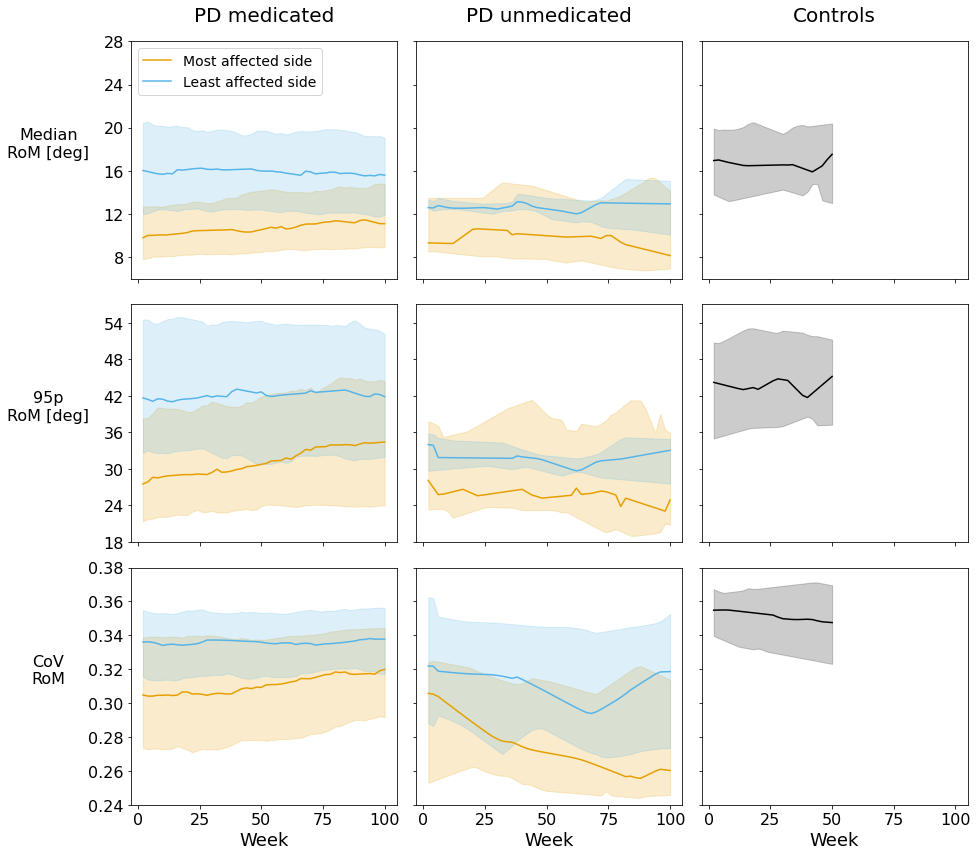

In [21]:
filter_type = 'filtered'
static_or_dynamic = 'static'
segment_length = '0_20'

interpolated = True
plot_controls = True

plot_measures = {
    'median': 'Median',
    '95p': '95p',
    'median_cov': 'CoV'
}

if plot_controls:
    ncols = 3
    groups = ['pd_med', 'pd_no_med', 'controls']
else:
    ncols = 2
    groups = ['pd_med', 'pd_no_med']

fig, ax = plt.subplots(nrows=len(plot_measures), ncols=ncols, figsize=(ncols * 4.5, 12), sharex=True, sharey=False)

for i, measure in enumerate(plot_measures):
    for j, group in enumerate(groups):
        if 'pd' in group:
            weeks = weeks_2y
            population = 'pd'
            med_state = group.split('pd_')[1]
        else:
            weeks = weeks_1y
            population = 'controls'

        path_to_measures = os.path.join(BASE_PATH, 'measures', f'{filter_type}_gait', segment_length)

        if interpolated:
            signal_values = pd.read_csv(os.path.join(path_to_measures, f'{population}_signal_interp_{measure}_range_of_motion.csv'))   
        else:
            signal_values = pd.read_csv(os.path.join(path_to_measures, f'{population}_signal_{measure}_range_of_motion.csv'))   

        iqr_list = []
        for week in weeks:
            week_measures = signal_values[f'week{week}']
            if population == 'pd':
                for aff_side in ['mas', 'las']:
                    if static_or_dynamic == 'static':
                        valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][f'{final_week_2y}']
                    else:
                        valid_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(week)]
                        
                    filtered_measures = [week_measures[idx] for idx in week_measures.index if pd_ids[idx] in valid_ids and pd.notna(week_measures[idx])]

                    iqr_list.append([
                        week,
                        aff_side,
                        np.nanpercentile(filtered_measures, 25), 
                        np.nanpercentile(filtered_measures, 50), 
                        np.nanpercentile(filtered_measures, 75)
                    ])   

                    if week == start_week and aff_side == 'mas':
                        N_mas = len(filtered_measures)
                    elif week == start_week:
                        N_las = len(filtered_measures)

            else:
                if static_or_dynamic == 'static':
                    valid_ids = srm_ids_per_week[segment_length][population][f'{final_week_1y}']
                else:
                    valid_ids = srm_ids_per_week[segment_length][population][str(week)]

                filtered_measures = [week_measures[idx] for idx in week_measures.index if controls_ids[idx] in valid_ids]
                aff_side = 'ctrl'

                iqr_list.append([
                    week,
                    aff_side,
                    np.nanpercentile(filtered_measures, 25), 
                    np.nanpercentile(filtered_measures, 50), 
                    np.nanpercentile(filtered_measures, 75)
                ])   
            
                if week == start_week:
                    N = len(filtered_measures)

        df_iqr = pd.DataFrame(iqr_list)
        df_iqr.columns = ['week', 'aff_side', '25p', '50p', '75p']

        if population == 'pd':
            for aff_side, color in zip(['mas', 'las'], [COLOR_GROUP_1, COLOR_GROUP_2]):
                df_aff = df_iqr.loc[df_iqr['aff_side']==aff_side]
                sns.lineplot(df_aff, x='week', y='50p', ax=ax[i,j], color=color, label=f'{AFFECTED_SIDE_RENAMING[aff_side]}')
                ax[i,j].fill_between(df_aff['week'], df_aff['25p'], df_aff['75p'], alpha=0.2, color=color)#, label=f'IQR ({AFFECTED_SIDE_RENAMING[aff_side]})')

        else:
            sns.lineplot(df_iqr, x='week', y='50p', ax=ax[i,j], color='black')#, label='Median')
            ax[i,j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black')#, label='IQR')

        if j != 2:
            ax[i,j].get_legend().remove()

        if i == 0:
            ax[i,j].set_title(GROUP_RENAMING[group], size=20, pad=20)

        ax[i,j].set_xlabel('Week', size=18)

        if i == 2:
            ax[i,j].set_ylabel(f'{plot_measures[measure]}\nRoM', size=PLOT_LABELSIZE, rotation=0, labelpad=40)
        else:
            ax[i,j].set_ylabel(f'{plot_measures[measure]}\nRoM [deg]', size=PLOT_LABELSIZE, rotation=0, labelpad=40)

        ax[i,j].tick_params(labelsize=16)
        ax[i,j].yaxis.set_major_locator(MaxNLocator(nbins=7))

        if population == 'pd':
            print(f"- {GROUP_RENAMING[group]}: {N_mas} MAS, {N_las} LAS")
        else:
            print(f"- {GROUP_RENAMING[group]}: {N}")

ax[0, 0].legend(loc='upper left', fontsize=14)

for i in range(len(plot_measures)):
    for j in range(1, 3):
        ax[i, j].sharey(ax[i, 0])
        ax[i, j].set_ylabel('')
        ax[i, j].tick_params(labelleft=False)
    
for j in range(ncols):
    if segment_length == '20_inf':
        ax[0, j].set_ylim([6, 45])
        ax[1, j].set_ylim([14, 76])
        ax[2, j].set_ylim([0.19, 0.36])
    else:
        ax[0, j].set_ylim([6, 28])
        ax[1, j].set_ylim([18, 57])
        ax[2, j].set_ylim([0.24, 0.38])

plt.tight_layout()
fig.align_ylabels(ax[:, 0])
plt.show()

if save_plots:
    fig.savefig(os.path.join(PATH_FIGURES, f"sr_descr_rom_abs_{segment_length}.png"), dpi=600, bbox_inches='tight')
    fig.savefig(os.path.join(PATH_FIGURES, 'vectors', f"sr_descr_rom_abs_{segment_length}.pdf"), dpi=600, bbox_inches='tight')

- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29
- PD medicated: 187 MAS, 114 LAS
- PD unmedicated: 17 MAS, 5 LAS
- Controls: 29


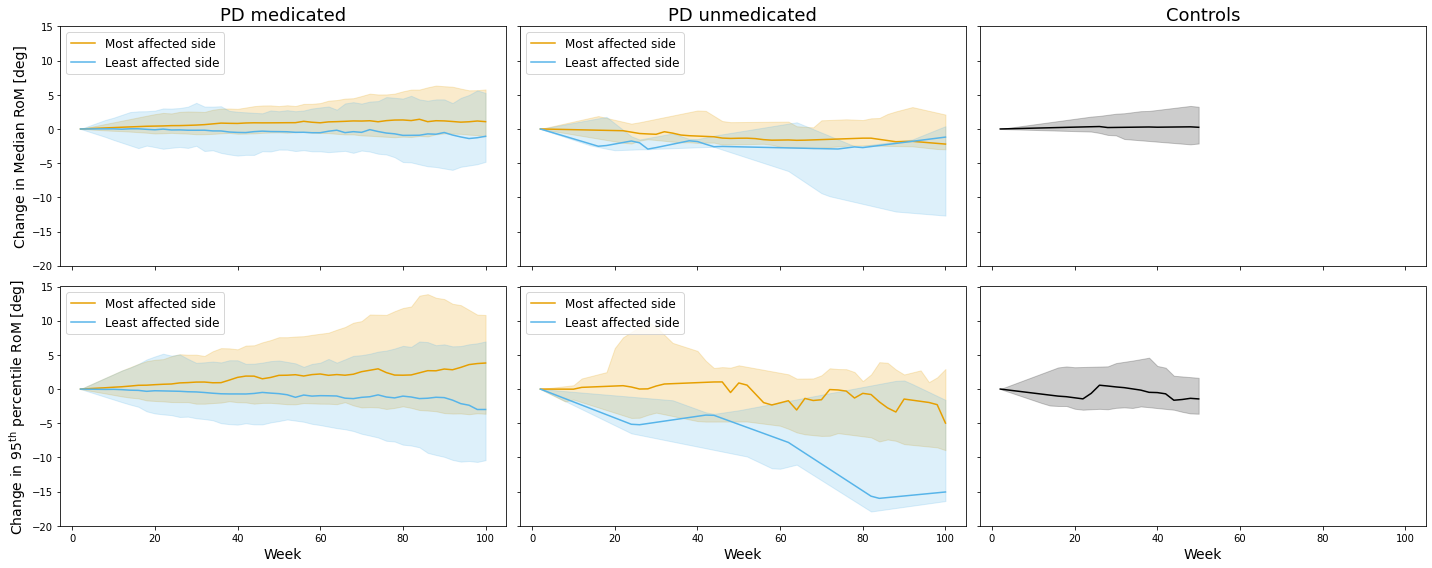

In [ ]:
filter_type = 'filtered'
static_or_dynamic = 'static'
segment_length = '20_inf'
start_week = 2

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(20, 8), sharex=True, sharey=True)

for i, measure in enumerate(['median', '95p']):
    for j, group in enumerate(['pd_med', 'pd_no_med', 'controls']):
        if 'pd' in group:
            weeks = weeks_2y
            population = 'pd'
            med_state = group.split('pd_')[1]
        else:
            weeks = weeks_1y
            population = 'controls'

        path_to_measures = BASE_PATH / 'measures' / f'{filter_type}_gait' / segment_length
        interpolated_measures = pd.read_csv(os.path.join(path_to_measures, f'{population}_signal_interp_{measure}_range_of_motion.csv'))

        start_week_measures = interpolated_measures[f'week{start_week}']

        iqr_list = []
        for week in weeks:
            week_measures = interpolated_measures[f'week{week}']
            if population == 'pd':
                for aff_side in ['mas', 'las']:
                    start_week_ids = srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(start_week)]
                    if static_or_dynamic == 'static':
                        valid_ids = [id for id in srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][f'{final_week_2y}'] if id in start_week_ids]
                    else:
                        valid_ids = [id for id in srm_ids_per_week[segment_length][f'{population}_{aff_side}_{med_state}'][str(week)] if id in start_week_ids]
                        
                    filtered_measures = [week_measures[idx] - start_week_measures[idx] for idx in week_measures.index if pd_ids[idx] in valid_ids and pd.notna(week_measures[idx])]

                    iqr_list.append([
                        week,
                        aff_side,
                        np.nanpercentile(filtered_measures, 25), 
                        np.nanpercentile(filtered_measures, 50), 
                        np.nanpercentile(filtered_measures, 75)
                    ])   

                    if week == start_week and aff_side == 'mas':
                        N_mas = len(filtered_measures)
                    elif week == start_week:
                        N_las = len(filtered_measures)
            else:
                start_week_ids = srm_ids_per_week[segment_length][population][str(start_week)]
                if static_or_dynamic == 'static':
                    valid_ids = [id for id in srm_ids_per_week[segment_length][population][f'{final_week_1y}'] if id in start_week_ids]
                else:
                    valid_ids = [id for id in srm_ids_per_week[segment_length][population][str(week)] if id in start_week_ids]

                filtered_measures = [week_measures[idx] - start_week_measures[idx] for idx in week_measures.index if controls_ids[idx] in valid_ids]

                iqr_list.append([
                    week,
                    aff_side,
                    np.nanpercentile(filtered_measures, 25), 
                    np.nanpercentile(filtered_measures, 50), 
                    np.nanpercentile(filtered_measures, 75)
                ])   
            
                if week == start_week:
                    N = len(filtered_measures)

        df_iqr = pd.DataFrame(iqr_list)
        df_iqr.columns = ['week', 'aff_side', '25p', '50p', '75p']

        if population == 'pd':
            for aff_side, color in zip(['mas', 'las'], [COLOR_GROUP_1, COLOR_GROUP_2]):
                df_aff = df_iqr.loc[df_iqr['aff_side']==aff_side]
                sns.lineplot(df_aff, x='week', y='50p', ax=ax[i,j], label=AFFECTED_SIDE_RENAMING[aff_side], color=color)
                ax[i,j].fill_between(df_aff['week'], df_aff['25p'], df_aff['75p'], alpha=0.2, color=color)
        else:
            sns.lineplot(df_iqr, x='week', y='50p', ax=ax[i,j], label='Controls', color='black')
            ax[i,j].fill_between(df_iqr['week'], df_iqr['25p'], df_iqr['75p'], alpha=0.2, color='black')

        ax[1,j].set_ylim([-20, 15])

        ax[i,j].set_ylabel(f'Change in {AGGREGATION_RENAMING[measure]} RoM [deg]', size=14)
        ax[i,j].set_xlabel('Week', size=14)
        ax[i,j].legend(loc='upper left', fontsize=12)

        if population == 'pd':
            print(f"- {GROUP_RENAMING[group]}: {N_mas} MAS, {N_las} LAS")
        else:
            print(f"- {GROUP_RENAMING[group]}: {N}")

ax[0, 0].set_title('PD medicated', size=PLOT_TITLESIZE)
ax[0, 1].set_title('PD unmedicated', size=PLOT_TITLESIZE)
ax[0, 2].set_title('Controls', size=PLOT_TITLESIZE)

for i in range(2):
    ax[i, 2].legend().remove()

plt.tight_layout()
plt.show()